<h1><center><b>IBM HR Analytics Employee Attrition Modeling</b></center></h1>

**IBM HR Analytics Employee Attrition Modeling** 
- It refers to a data science project or case study, often used in analytics and machine learning, where a dataset provided by IBM is used to analyze and predict employee attrition — that is, when employees leave a company.

- Here's a breakdown of the phrase:
    - **IBM :** The dataset comes from IBM or is modeled after a realistic corporate setting, often shared for educational or analytical purposes.

    - **HR Analytics:** Human Resources Analytics involves using data and statistical methods to understand HR metrics such as employee performance, satisfaction, recruitment, and attrition.

    - **Employee Attrition:** This means employees leaving the company, either voluntarily (resignation) or involuntarily (layoffs, termination).

    - **Modeling:** Building predictive models (typically using machine learning) to understand and predict which employees are at risk of leaving, based on various features (e.g., job role, salary, age, work-life balance).

# Objectives of the project:
- Understand the key factors that contribute to employee turnover.

- Build predictive models (e.g., logistic regression, decision trees) to identify employees likely to leave.

- Support HR decision-making to improve employee retention and reduce turnover costs.

**Dataset features (examples):**
- Age, Gender, Job Role

- Years at company

- Monthly income

- Job satisfaction

- Work-life balance

- Overtime (Yes/No)

- Performance rating

- Attrition (Yes/No) → Target variable

# Data Dictionary :

- **Age :** Age of employee
- **Attrition :** Employee attrition status
- **Department :**
    - Department of work
    - Distance from Home

- **Education :**
    - 1 : Below College
    - 2 : College
    - 3 : Bachelor
    - 4 : Master
    - 5 : Doctor

- **EducationField**
- **Environment Satisfaction :**
    - 1 : Low
    - 2 : Medium
    - 3 : High
    - 4 : Very High

- **Job Satisfaction :**
    - 1 : Low
    - 2 : Medium
    - 3 : High
    - 4 : Very High

- **MaritalStatus**
  
- **MonthlyIncome**

- **Number of Companies Worked :**
  Number of companies worked prior to IBM
  
- **Work Life Balance :**
    - 1 : Bad
    - 2 : Good
    - 3 : Better
    - 4 : Best
      
**Years At Company :** Current years of service in IBM
  
**Analysis Task :**
- Import attrition dataset and import libraries such as **pandas**, **matplotlib.pyplot**, **numpy**, and **seaborn.**
- Exploratory data analysis

**Find the age distribution of employees in IBM**

**Explore attrition by age**

**Explore data for Left employees**

**Find out the distribution of employees by the education field**

**Give a bar chart for the number of married and unmarried employees**

**Build up a logistic regression model to predict which employees are likely to attrite.**

# Import the libraries :

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score

In [5]:
# Accessing the dataset
dataset=pd.read_csv(r"E:\Python Projects\Personal Projects\Data Files\IBM Attrition Data.csv")
dataset

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Research & Development,23,2,Medical,3,4,Married,2571,4,3,5
1466,39,No,Research & Development,6,1,Medical,4,1,Married,9991,4,3,7
1467,27,No,Research & Development,4,3,Life Sciences,2,2,Married,6142,1,3,6
1468,49,No,Sales,2,3,Medical,4,2,Married,5390,2,2,9


In [7]:
# Getting info of the dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   DistanceFromHome         1470 non-null   int64 
 4   Education                1470 non-null   int64 
 5   EducationField           1470 non-null   object
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   MaritalStatus            1470 non-null   object
 9   MonthlyIncome            1470 non-null   int64 
 10  NumCompaniesWorked       1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsAtCompany           1470 non-null   int64 
dtypes: int64(9), object(4)
memory usage: 149.4+ KB


In [9]:
# Describe function
dataset.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.728571,6502.931293,2.693197,2.761224,7.008163
std,9.135373,8.106864,1.024165,1.093082,1.102846,4707.956783,2.498009,0.706476,6.126525
min,18.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,2911.000000,1.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,4919.000000,2.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,4.000000,4.000000,8379.000000,4.000000,3.000000,9.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,19999.000000,9.000000,4.000000,40.000000


In [19]:
# Column names
columns_=dataset.columns.values
columns_

array(['Age', 'Attrition', 'Department', 'DistanceFromHome', 'Education',
       'EducationField', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked',
       'WorkLifeBalance', 'YearsAtCompany'], dtype=object)

In [21]:
type(columns_)

numpy.ndarray

<h1><b><center>Exploratory Data Analysis :</center></b></h1>

In [26]:
# Extracting the ages from the dataset
age = dataset['Age'].value_counts()
age_groups = age.keys().values

age_groups

array([35, 34, 36, 31, 29, 32, 30, 33, 38, 40, 37, 27, 28, 42, 39, 45, 41,
       26, 44, 46, 43, 50, 25, 24, 49, 47, 55, 51, 53, 48, 54, 52, 22, 56,
       23, 58, 21, 20, 59, 19, 18, 60, 57], dtype=int64)

In [28]:
# Checking the age groups type
type(age_groups)

numpy.ndarray

In [30]:
# separating the age count from the age dataframe
age_count_for_age_groups = []

for i in age_groups:
    age_count_for_age_groups.append(age[i])

# converting it into numpy array
age_count_for_age_groups = np.array(age_count_for_age_groups)

# showing the age count
age_count_for_age_groups

array([78, 77, 69, 69, 68, 61, 60, 58, 58, 57, 50, 48, 48, 46, 42, 41, 40,
       39, 33, 33, 32, 30, 26, 26, 24, 24, 22, 19, 19, 19, 18, 18, 16, 14,
       14, 14, 13, 11, 10,  9,  8,  5,  4], dtype=int64)

In [32]:
# Data type of count data
type(age_count_for_age_groups)

numpy.ndarray

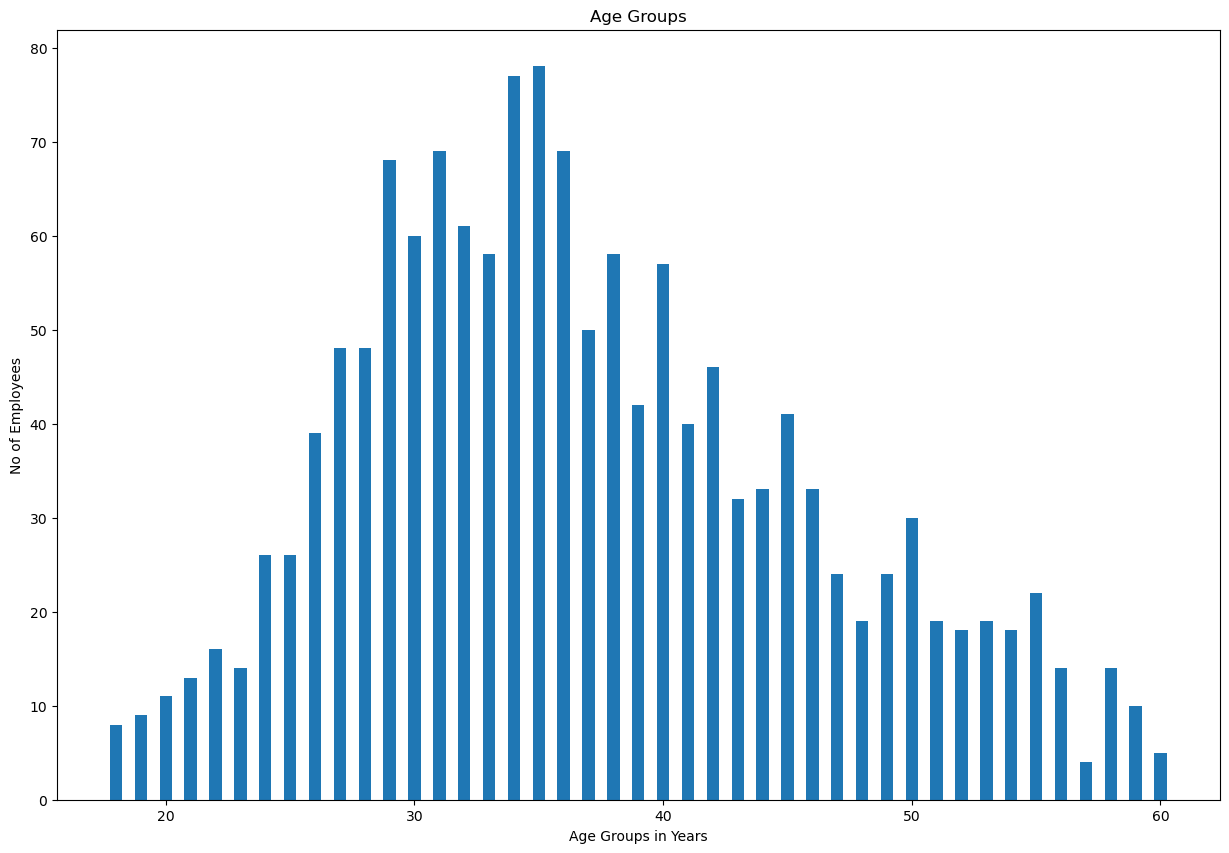

In [35]:
# PLotting Bar graph for Age Groups
plt.figure(figsize=(15,10))

# for making the background white
ax = plt.axes()
ax.set_facecolor('white')

plt.bar(age_groups, age_count_for_age_groups, width=0.5)
plt.xlabel('Age Groups in Years')
plt.ylabel('No of Employees')
plt.title('Age Groups')
plt.show()

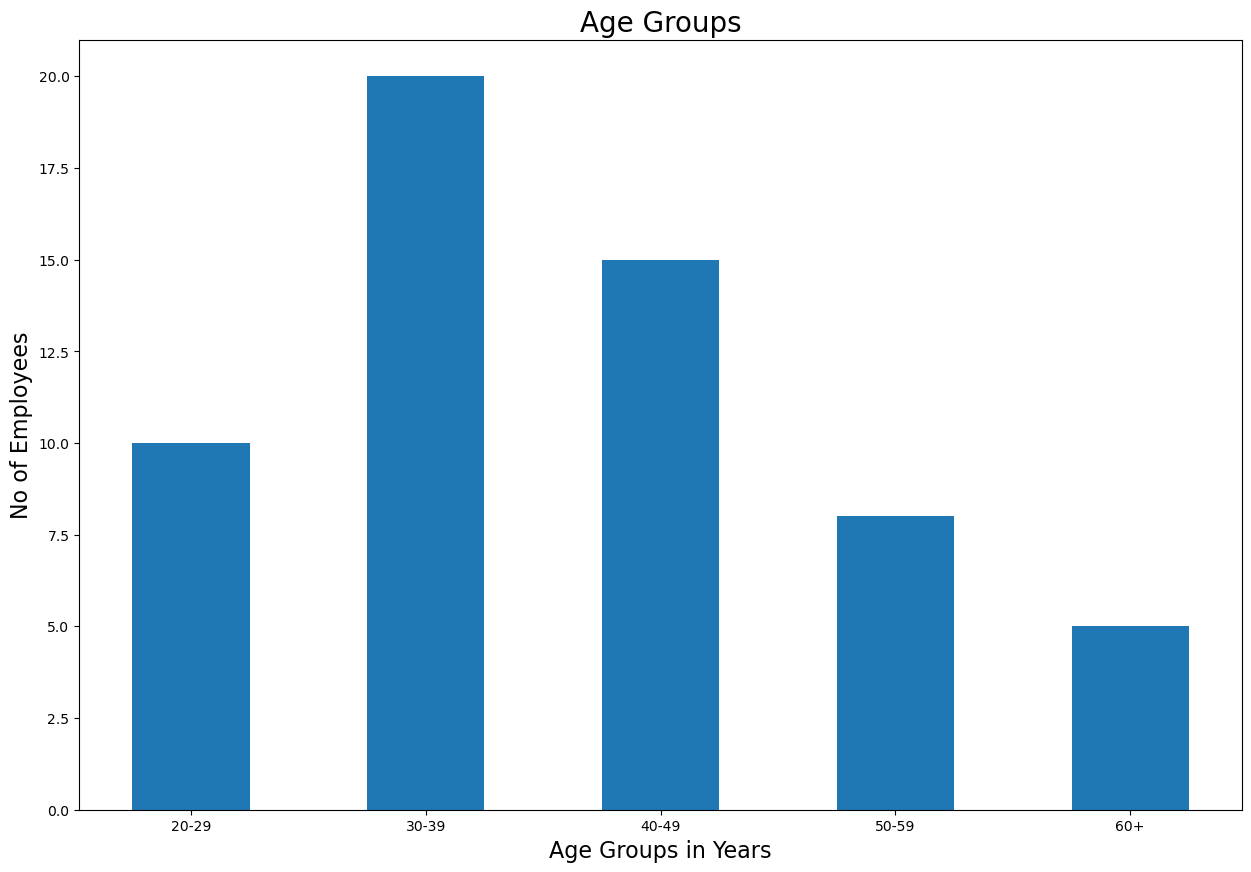

In [41]:
# PLotting Bar graph for Age Groups
plt.figure(figsize=(15,10))

# for making the background white
ax = plt.axes()
ax.set_facecolor('white')

plt.bar(age_groups, age_count_for_age_groups, width=0.5)
plt.xlabel('Age Groups in Years', fontsize=16)
plt.ylabel('No of Employees', fontsize=16)
plt.title('Age Groups', fontsize=20)
plt.show()

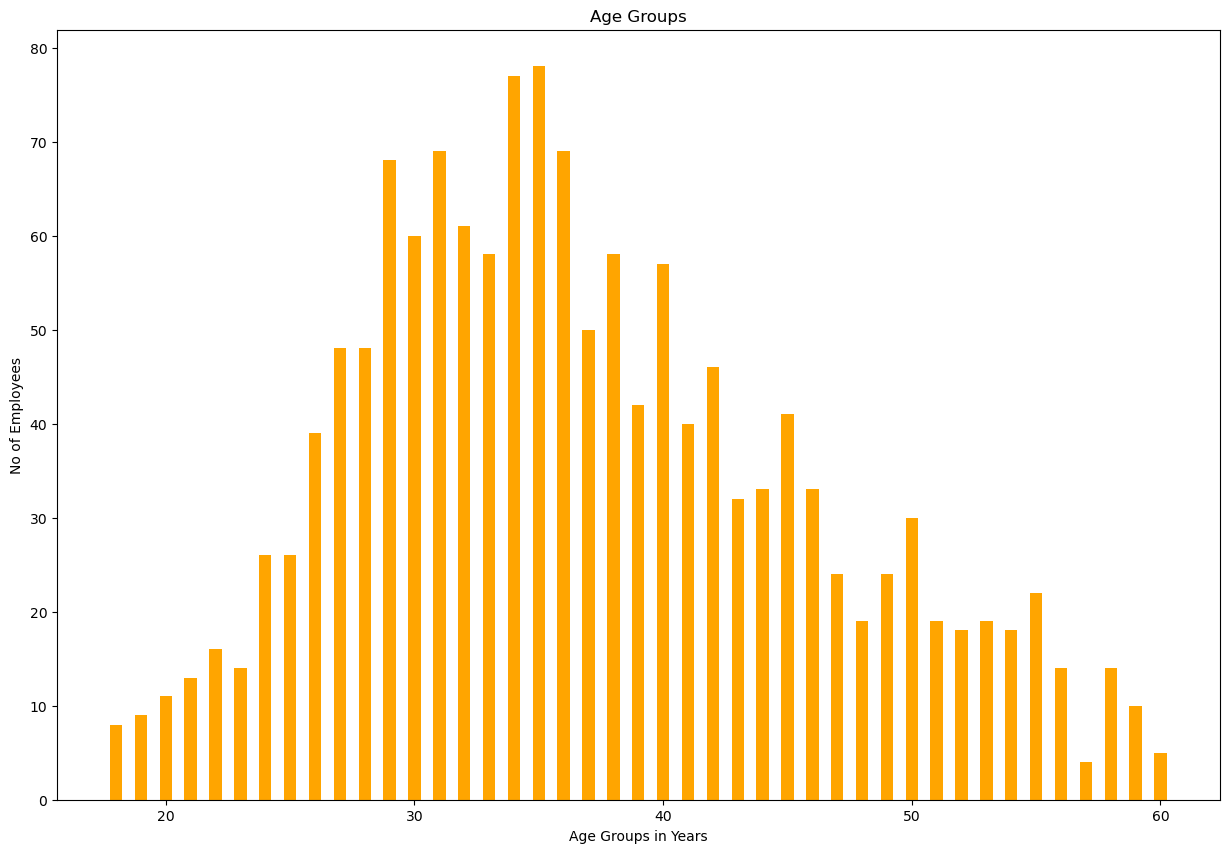

In [37]:
# PLotting Bar graph for Age Groups
plt.figure(figsize=(15,10))

# for making the background white
ax = plt.axes()
ax.set_facecolor('white')

plt.bar(age_groups, age_count_for_age_groups, width=0.5, color='orange')
plt.xlabel('Age Groups in Years')
plt.ylabel('No of Employees')
plt.title('Age Groups')
plt.show()

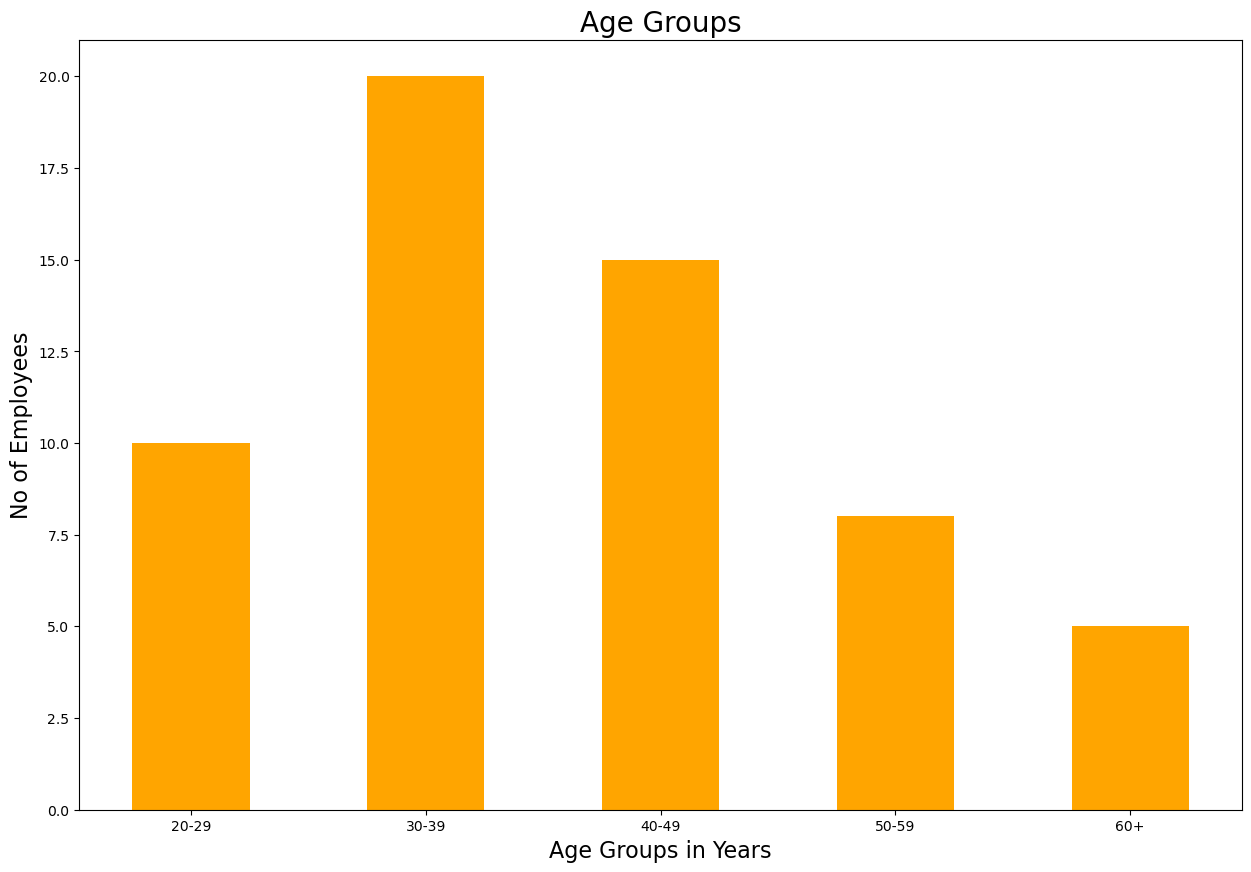

In [43]:
# PLotting Bar graph for Age Groups
plt.figure(figsize=(15,10))

# for making the background white
ax = plt.axes()
ax.set_facecolor('white')

plt.bar(age_groups, age_count_for_age_groups, width=0.5, color='orange')
plt.xlabel('Age Groups in Years', fontsize=16)
plt.ylabel('No of Employees', fontsize=16)
plt.title('Age Groups', fontsize=20)
plt.show()

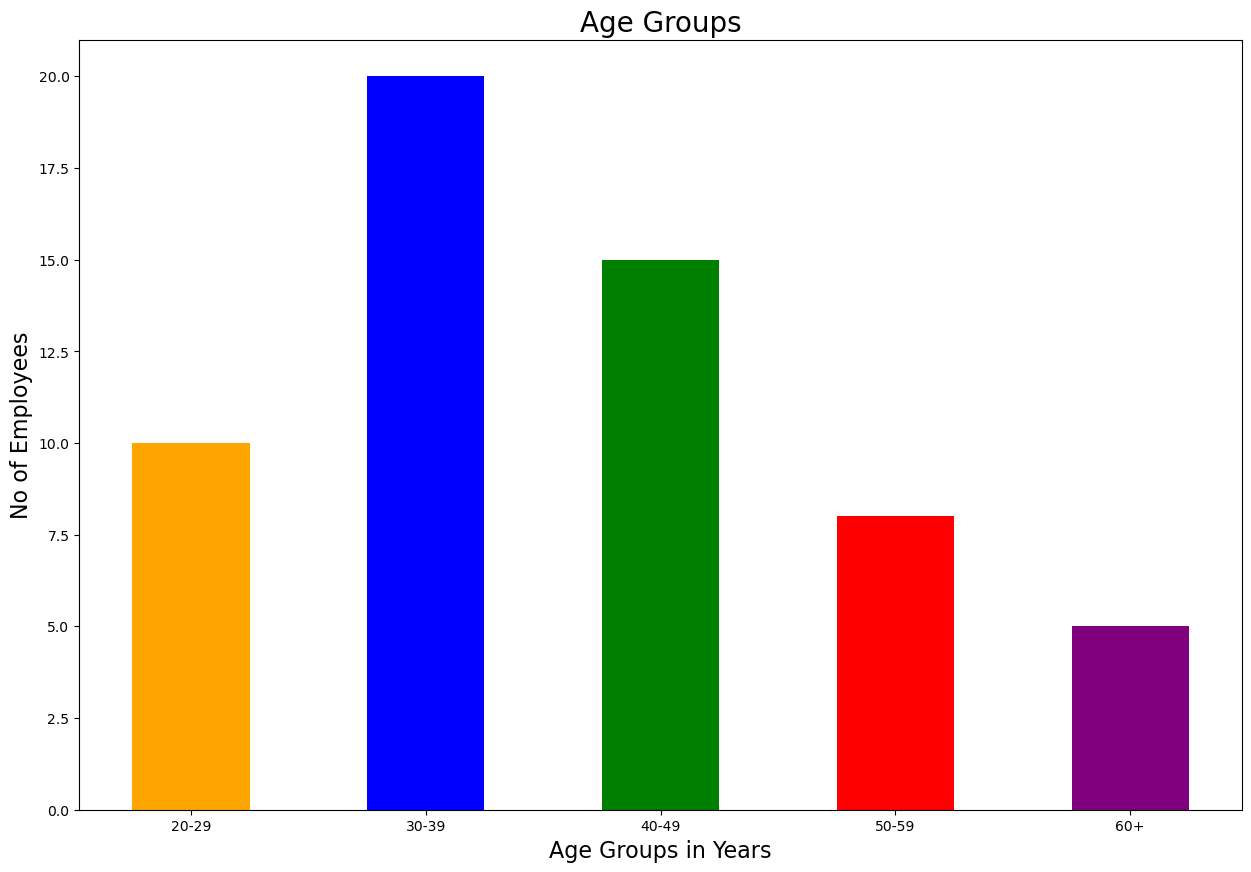

In [45]:
import matplotlib.pyplot as plt

# Sample data
age_groups = ['20-29', '30-39', '40-49', '50-59', '60+']
age_count_for_age_groups = [10, 20, 15, 8, 5]

# Define a list of colors (same length as age_groups)
colors = ['orange', 'blue', 'green', 'red', 'purple']

plt.figure(figsize=(15, 10))

# Set background to white
ax = plt.axes()
ax.set_facecolor('white')

# Pass the list of colors
plt.bar(age_groups, age_count_for_age_groups, width=0.5, color=colors)

plt.xlabel('Age Groups in Years', fontsize=16)
plt.ylabel('No of Employees', fontsize=16)
plt.title('Age Groups', fontsize=20)
plt.show()

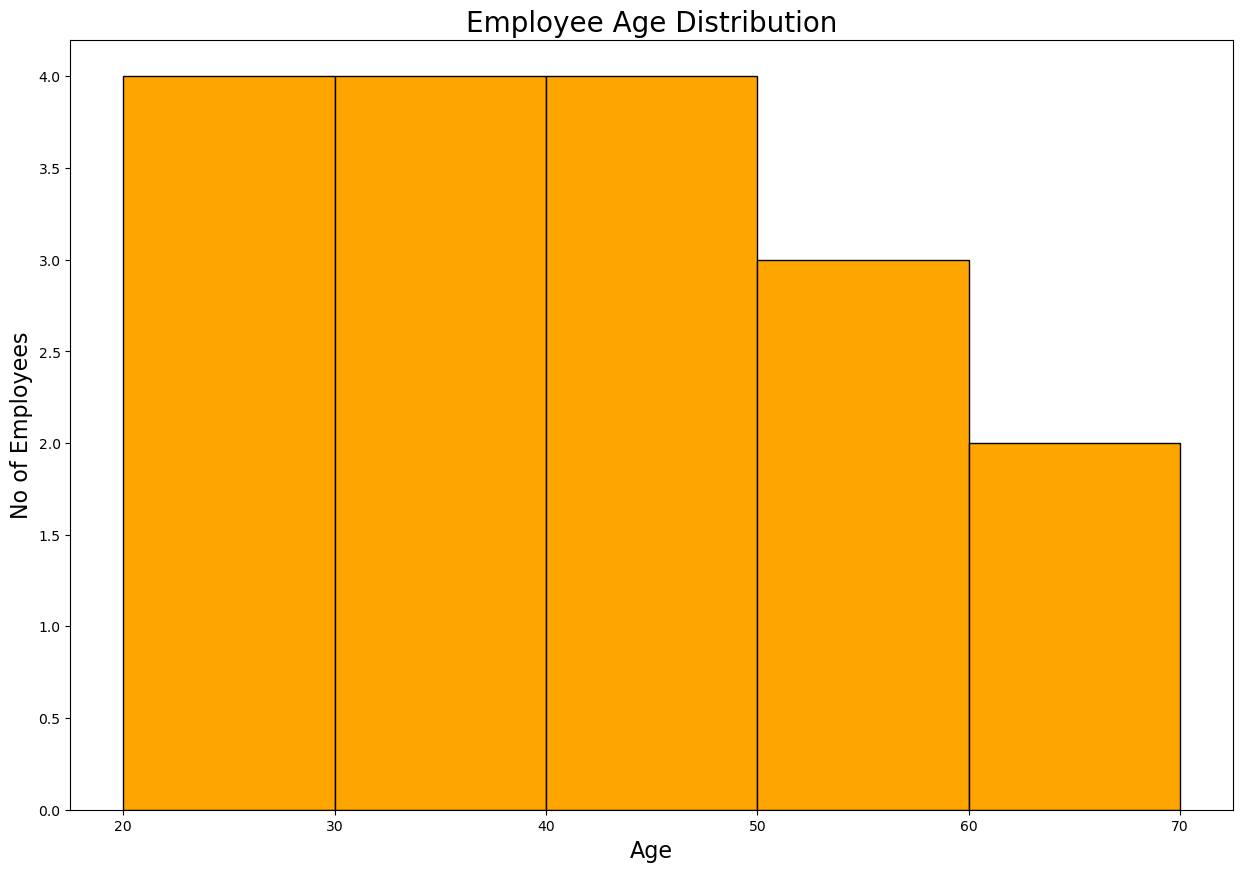

In [64]:
# %matplotlib inline  # Uncomment if not already set in your Jupyter notebook

import matplotlib.pyplot as plt

# Clear previous figures
plt.close('all')

# Define raw age data
ages = [22, 25, 29, 34, 35, 41, 45, 52, 56, 60, 63, 38, 40, 48, 59, 27, 31]

# Create figure and axes
fig, ax = plt.subplots(figsize=(15, 10))

# Set background color
ax.set_facecolor('white')

# Histogram with custom bins
bins = [20, 30, 40, 50, 60, 70]
ax.hist(ages, bins=bins, color='orange', edgecolor='black')

# Labels and title
ax.set_xlabel('Age', fontsize=16)
ax.set_ylabel('No of Employees', fontsize=16)
ax.set_title('Employee Age Distribution', fontsize=20)

# Show the plot
plt.show()

# Exploring attrition by Age :

<b>1. Number of 'Yes' and 'No' Counts i.e. No of people are under attrition type Yes and No</b>

In [66]:
# extracting the age column
attrition_data = dataset['Attrition']
attrition_data

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: object

In [68]:
# counting the total no of Yes and No under the Attrition column
attrition_data = dataset['Attrition']
opinions = attrition_data.value_counts()
opinions

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [70]:
opinion_types = opinions.keys()
opinion_types

Index(['No', 'Yes'], dtype='object', name='Attrition')

In [72]:
opinion_counts = [opinions[0], opinions[1]]
opinion_counts

C:\Users\TSTRANSCO\AppData\Local\Temp\ipykernel_10644\1746345588.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opinion_counts = [opinions[0], opinions[1]]


[1233, 237]

In [ ]:
# plt.figure(figsize=(10,7))
# ax = plt.axes()
# ax.set_facecolor('white')
# plt.bar(opinion_types, opinion_counts, color='r', width=0.5)
# plt.xlabel('Attrition types')
# plt.ylabel('Count')
# plt.title('Attrition')
# plt.grid(color='blue', linestyle='-', linewidth=0.5)
# plt.show()

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a common function to plot categorical columns
def category_plot(attr):
    sns.set(rc={'axes.facecolor': 'white', 'figure.facecolor': 'white'})
    
    # Capture the catplot object
    g = sns.catplot(data=dataset, kind='count', height=5, aspect=1.5, x=attr, legend=True)
    
    # Apply grid
    plt.grid(color='blue', linestyle='-', linewidth=0.5)
    
    # Render the plot explicitly
    plt.show()

In [78]:
# Plotting Attrition Column
category_plot('Attrition')

In [82]:
def category_plot(attr):
    sns.set(rc={'axes.facecolor': 'white', 'figure.facecolor': 'white'})
    
    # Create the catplot and assign it to a variable
    g = sns.catplot(data=dataset, kind='count', height=5, aspect=1.5, x=attr, legend=True)
    
    # Apply grid to current axes
    plt.grid(color='blue', linestyle='-', linewidth=0.5)
    
    # Show the plot explicitly
    plt.show()  # 👈 This makes sure the plot renders in notebooks

In [102]:
def category_plot(attr):
    plt.close('all')  # Close any existing plots
    
    sns.set(rc={'axes.facecolor': 'white', 'figure.facecolor': 'white'})
    g = sns.catplot(data=dataset, kind='count', height=5, aspect=1.5, x=attr, legend=True)
    
    plt.grid(color='blue')
    plt.show()

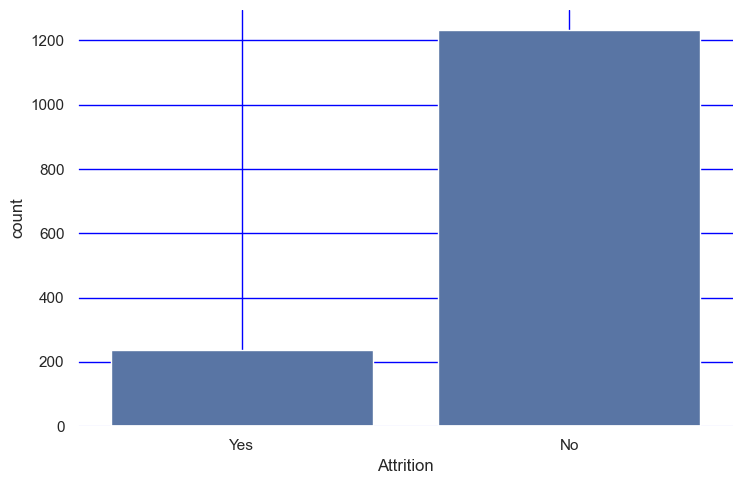

In [104]:
category_plot('Attrition')

In [106]:
def category_plot(attr):
    plt.close('all')  # Close any existing plots
    
    sns.set(rc={'axes.facecolor': 'white', 'figure.facecolor': 'white'})
    g = sns.catplot(data=dataset, kind='count', height=5, aspect=1.5, x=attr, legend=True)
    
    plt.show()

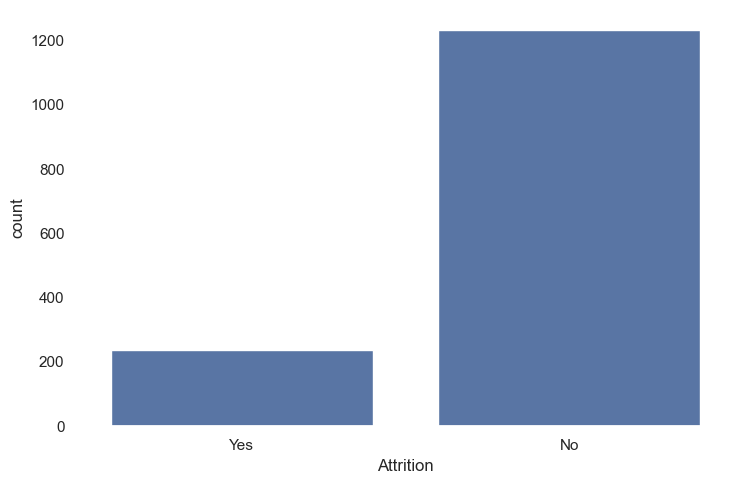

In [108]:
category_plot('Attrition')

C:\Users\TSTRANSCO\AppData\Local\Temp\ipykernel_10644\223772534.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=dataset, kind='count', height=5, aspect=1.5, x=attr, palette=palette)


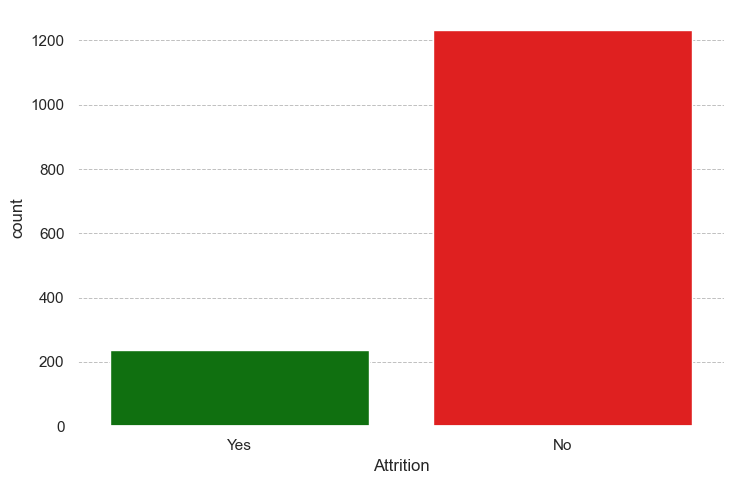

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

def category_plot(attr):
    plt.close('all')  # Clear previous plots
    
    sns.set(rc={'axes.facecolor': 'white', 'figure.facecolor': 'white'})
    
    # Define color mapping for Yes/No bars
    palette = {'Yes': 'green', 'No': 'red'}
    
    # Plot countplot with palette
    g = sns.catplot(data=dataset, kind='count', height=5, aspect=1.5, x=attr, palette=palette)
    
    # Optional grid on y axis only
    g.ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    
    plt.show()

# Call the function on 'Attrition' column
category_plot('Attrition')

<b>2. Now we'll try to find the age groups of the people who have been attrited and also who have not been attrited, i.e for the Left Employees</b>

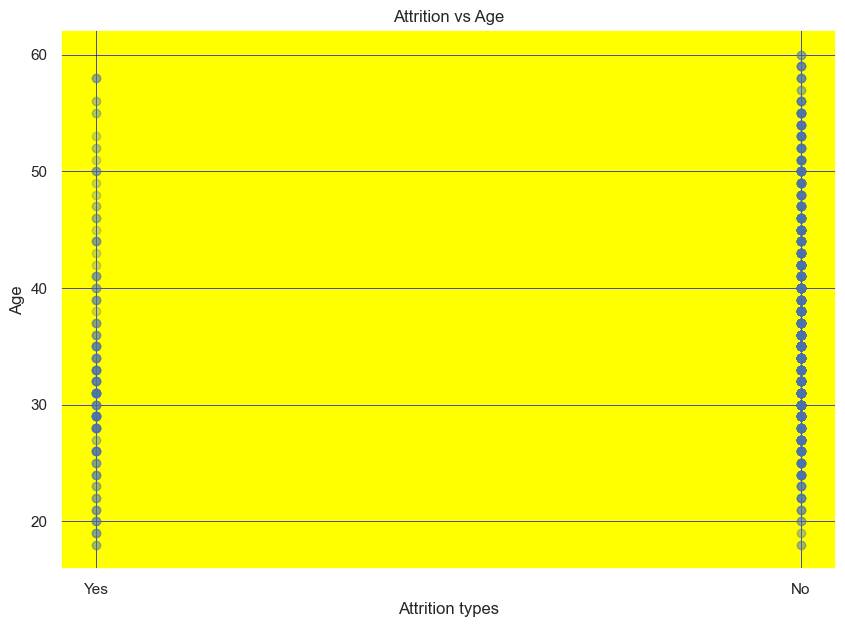

In [122]:
# Now plotting the Age column with the Attrition columnn
plt.figure(figsize=(10,7))
ax = plt.axes()
ax.set_facecolor('yellow')
plt.scatter(dataset['Attrition'], dataset['Age'], color='b', alpha=0.15)
plt.xlabel('Attrition types')
plt.ylabel('Age')
plt.title('Attrition vs Age')
plt.grid(color='blue', linestyle='-', linewidth=0.5)
plt.show()

# The blue points (color='b') will be drawn with low opacity.

# Overlapping points will appear darker where they cluster.

# This helps to visualize point density and reduce clutter in dense scatter plots.

# The alpha parameter in matplotlib controls the transparency (or opacity) of the plotted elements.

# alpha=0.15 mean?
# alpha ranges from 0 to 1:

# 0 means completely transparent (invisible).

# 1 means completely opaque (solid color).

# So alpha=0.15 means the points are very transparent (15% opacity).

# This is useful when you have lots of overlapping points — it helps you see density by letting overlapping points “stack up” visually.

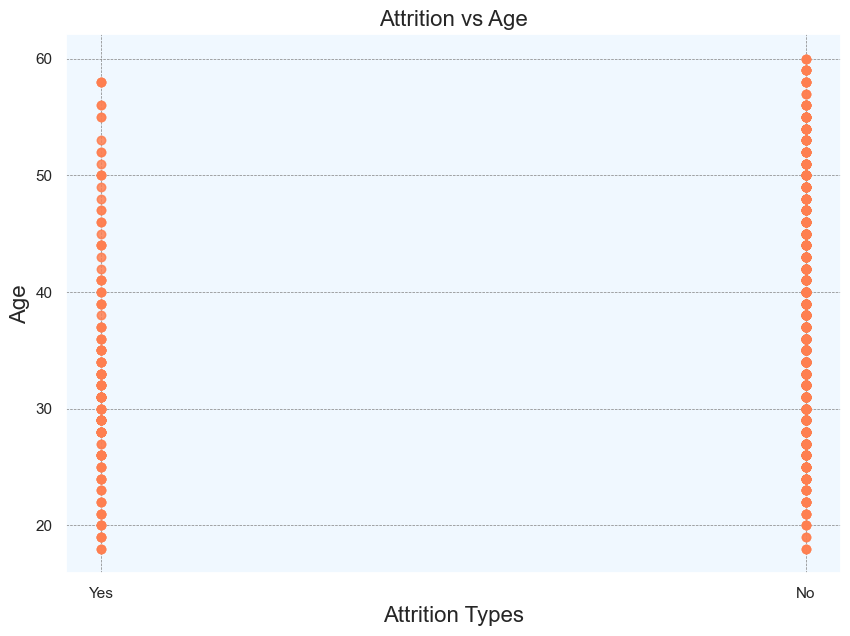

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
ax = plt.axes()

# Soft light facecolor
ax.set_facecolor('#f0f8ff')  # AliceBlue

# Scatter with a warm tone and some transparency
plt.scatter(dataset['Attrition'], dataset['Age'], color='#ff7f50', alpha=0.6)  # Coral color

plt.xlabel('Attrition Types', fontsize=16)
plt.ylabel('Age', fontsize=16)
plt.title('Attrition vs Age', fontsize=16)

# Grid with light grey lines for subtlety
plt.grid(color='gray', linestyle='--', linewidth=0.5)

plt.show()

# Conclusion drawn from the plot :
- So maximum number of people who have been **attributed** fall under the range of **25** to **40**.
- Whereas for the **not attributed** category the range seem to be allover the category itself.

# Distribution of Employees in the Educational field :

In [132]:
dataset=pd.read_csv(r"E:\Python Projects\Personal Projects\Data Files\IBM Attrition Data.csv")
dataset

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Research & Development,23,2,Medical,3,4,Married,2571,4,3,5
1466,39,No,Research & Development,6,1,Medical,4,1,Married,9991,4,3,7
1467,27,No,Research & Development,4,3,Life Sciences,2,2,Married,6142,1,3,6
1468,49,No,Sales,2,3,Medical,4,2,Married,5390,2,2,9


In [136]:
# extracting the educational field column
employee = dataset['EducationField']

In [138]:
# getting the counts of subjects under 'EducationField'
employee.value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [142]:
def category_plot(attr):
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Get unique categories
    unique_vals = dataset[attr].unique()

    # Generate a palette from Seaborn's color palette
    palette = sns.color_palette("husl", len(unique_vals))  # or try "Set2", "Paired", etc.
    palette_dict = dict(zip(unique_vals, palette))

    # Plot using dynamically created palette
    g = sns.catplot(data=dataset, kind='count', height=5, aspect=1.5, x=attr, palette=palette_dict)
    g.ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    plt.title(f'Count plot for {attr}')
    plt.xticks(rotation=45)
    plt.show()

In [144]:
def category_plot(attr):
    import seaborn as sns
    import matplotlib.pyplot as plt

    g = sns.catplot(data=dataset, kind='count', height=5, aspect=1.5, x=attr)
    g.ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    plt.title(f'Count plot for {attr}')
    plt.xticks(rotation=45)
    plt.show()

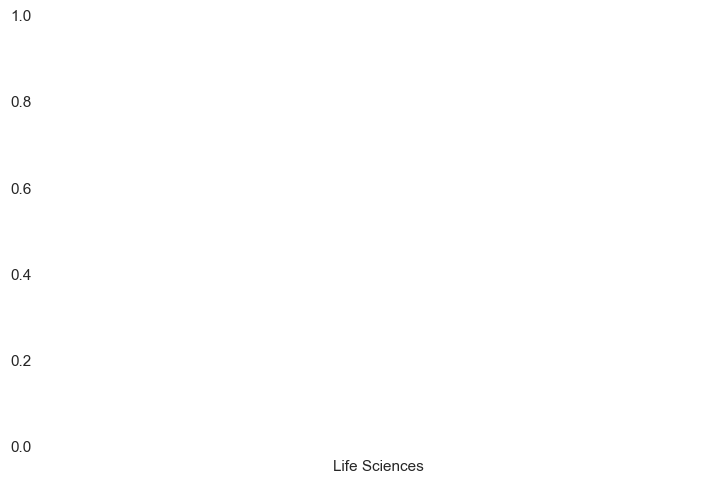

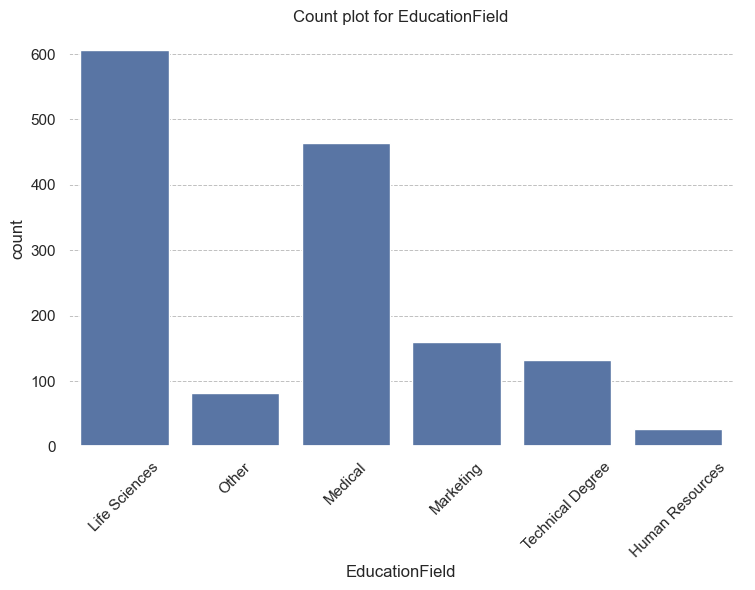

In [146]:
category_plot('EducationField')

# Conclusion drawn from the plot :
- Life Science is the educational field with **highest** employees
  
- Human Resource is the educational field with the **lowest** emplyees

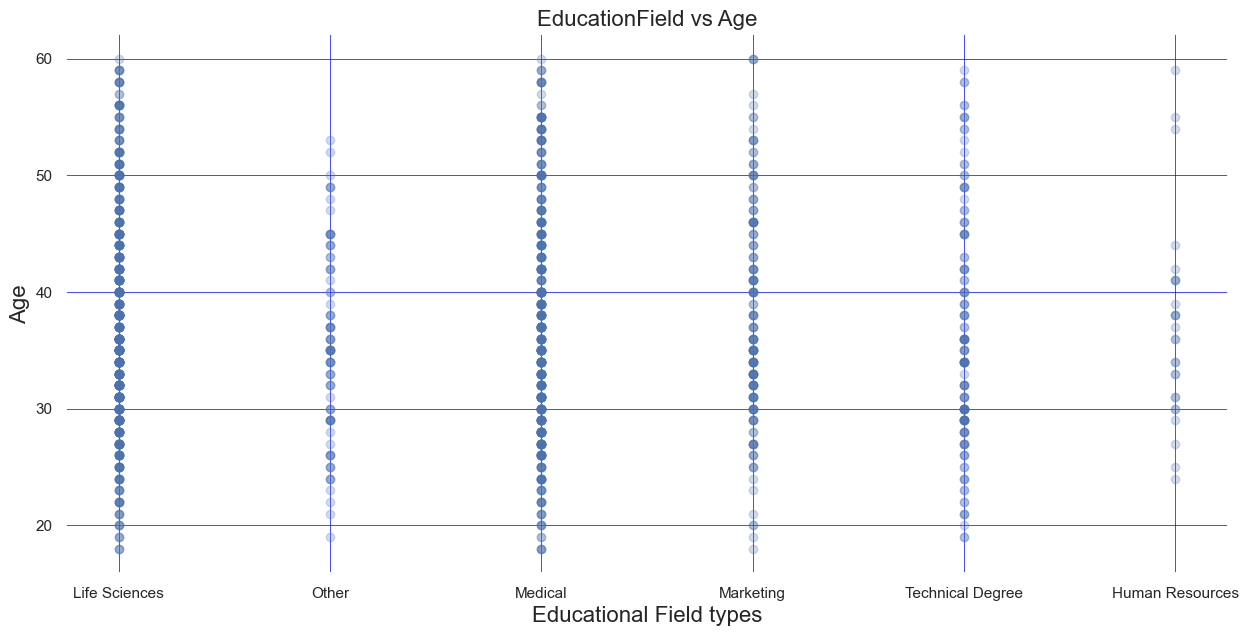

In [154]:
# Age distribution of employees among the educational fields
plt.figure(figsize=(15,7))
ax = plt.axes()
ax.set_facecolor('white')
plt.scatter(dataset['EducationField'], dataset['Age'], color='b', alpha=0.25)
plt.xlabel('Educational Field types', fontsize=16)
plt.ylabel('Age', fontsize=16)
plt.title('EducationField vs Age', fontsize=16)
plt.grid(color='blue', linestyle='-', linewidth=0.5)
plt.show()

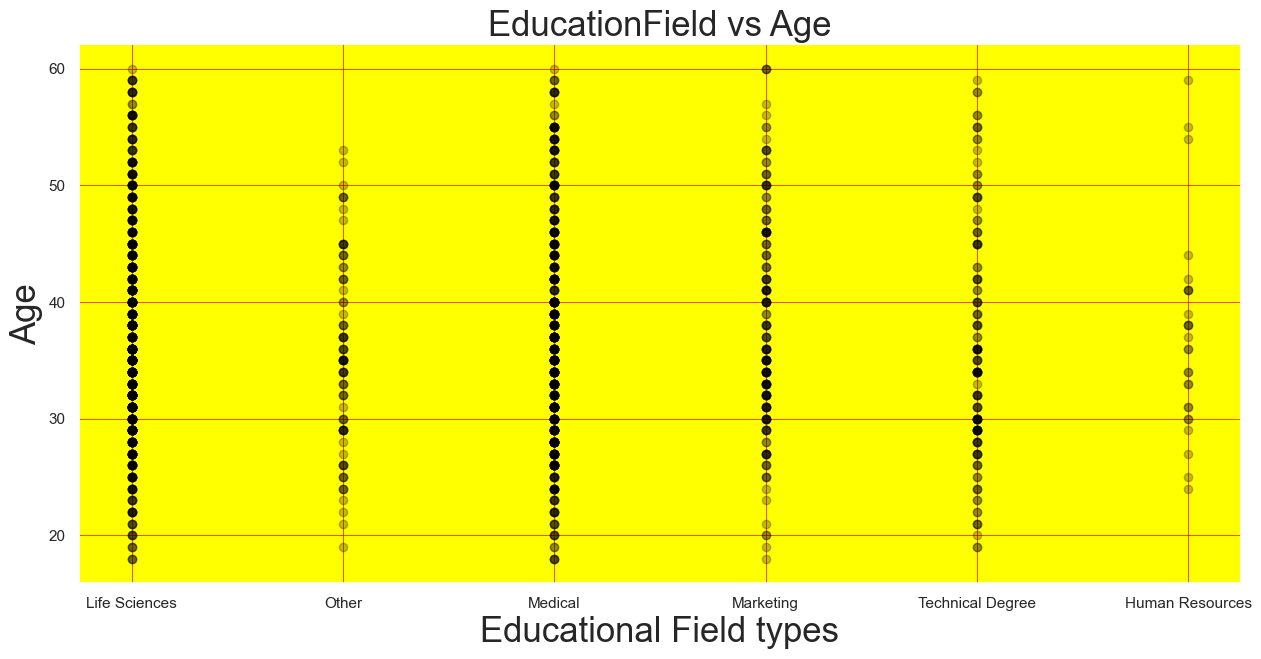

In [166]:
# Age distribution of employees among the educational fields
plt.figure(figsize=(15,7))
ax = plt.axes()
ax.set_facecolor('yellow')
plt.scatter(dataset['EducationField'], dataset['Age'], color='black', alpha=0.25)
plt.xlabel('Educational Field types', fontsize=25)
plt.ylabel('Age', fontsize=25)
plt.title('EducationField vs Age', fontsize=25)
plt.grid(color='red', linestyle='-', linewidth=0.5)
plt.show()

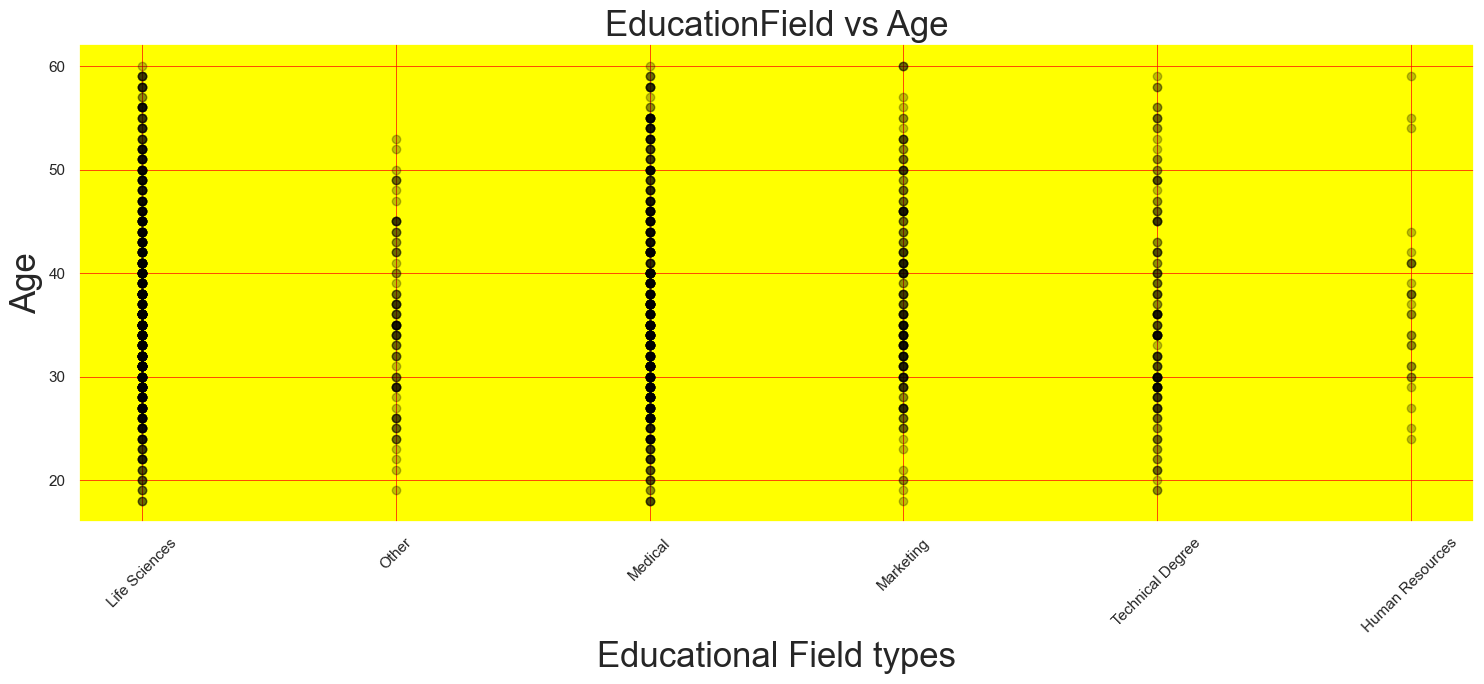

In [187]:
# Age distribution of employees among the educational fields
plt.figure(figsize=(15,7))
ax = plt.axes()
ax.set_facecolor('yellow')

# Scatter plot
plt.scatter(dataset['EducationField'], dataset['Age'], color='black', alpha=0.25)

# Labels and title
plt.xlabel('Educational Field types', fontsize=25)
plt.ylabel('Age', fontsize=25)
plt.title('EducationField vs Age', fontsize=25)

# Grid
plt.grid(color='red', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

C:\Users\TSTRANSCO\AppData\Local\Temp\ipykernel_10644\2663409569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x='EducationField', y='Age', palette='pastel')


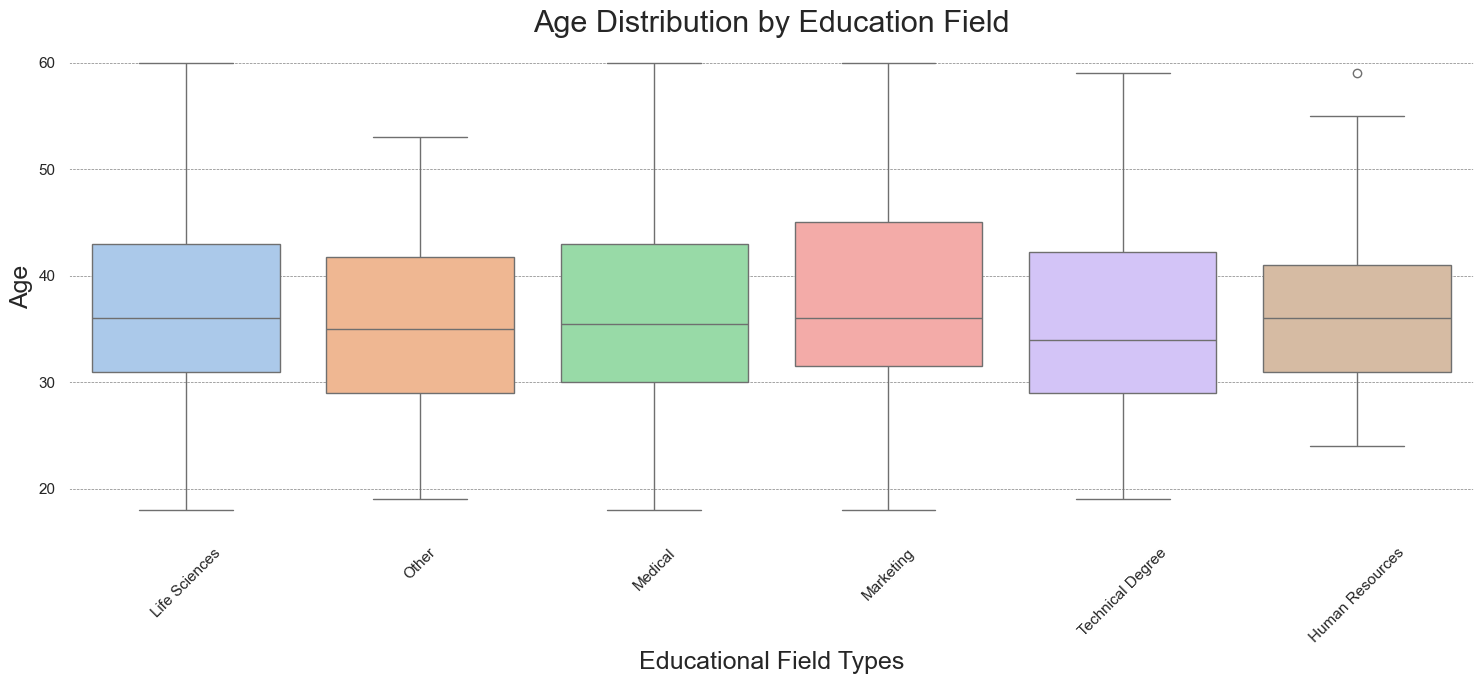

In [181]:
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.boxplot(data=dataset, x='EducationField', y='Age', palette='pastel')
plt.title('Age Distribution by Education Field', fontsize=22)
plt.xlabel('Educational Field Types', fontsize=18)
plt.ylabel('Age', fontsize=18)
plt.xticks(rotation=45)
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


# Conclusion drawn from the plot

- **Life Science** has employees from the age range of **18** to **60**
  
- **Medical** has employees from the age range of **18** to **60**

- **Marketig** has employees from the age range of **25** to **55**

- **Technical Degree** has employees from the age range of **20** to **50**

- Other has employees from the age range of **30** to **40**

- **Human Resource** has employees from the age range of **30** to **40** although it is very scarce over the range

# Pie chart for Maritial Status :

In [192]:
# extracting the MaritalStatus column
maritial_status = dataset['MaritalStatus']

In [194]:
# getting a count of the variables in the column
m = maritial_status.value_counts()
m

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

In [196]:
# getting the labels of the column
label = m.keys()
label

Index(['Married', 'Single', 'Divorced'], dtype='object', name='MaritalStatus')

In [198]:
# getting the label counts
label_counts = m.values
label_counts

array([673, 470, 327], dtype=int64)

In [200]:
def funtion_for_value(pct, all_value):       # pct - Percentage
    absolute = pct/100 *np.sum(all_value)
    return "{:.1f}%\n({:d})".format(pct, round(absolute))

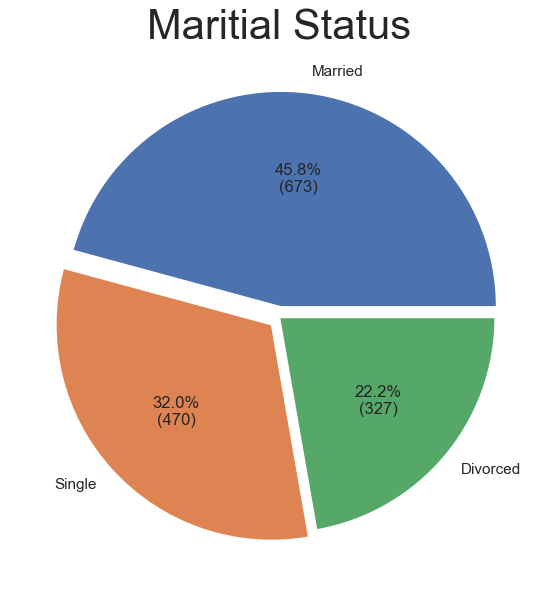

In [202]:
# plotting the pie chart
plt.figure(figsize=(7,7))
explode = (0.05, 0.05, 0)
plt.pie(label_counts, labels=label, explode=explode, autopct = lambda pct : funtion_for_value(pct, label_counts))
plt.title('Maritial Status', size=30)
plt.show()

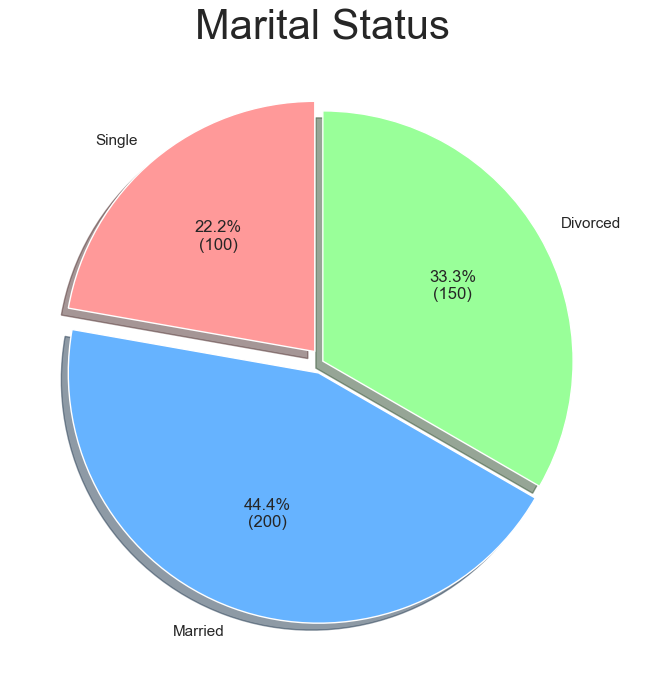

In [204]:
import matplotlib.pyplot as plt

# Example data (replace with your actual variables)
label_counts = [100, 200, 150]
label = ['Single', 'Married', 'Divorced']

# Function to format percentage and absolute count
def funtion_for_value(pct, all_value):
    absolute = pct / 100 * sum(all_value)
    return "{:.1f}%\n({:d})".format(pct, round(absolute))

# Custom colors for each slice
colors = ['#ff9999', '#66b3ff', '#99ff99']  # You can customize these

# Plotting the pie chart
plt.figure(figsize=(7, 7))
explode = (0.05, 0.05, 0)
plt.pie(label_counts,
        labels=label,
        explode=explode,
        autopct=lambda pct: funtion_for_value(pct, label_counts),
        colors=colors,
        shadow=True,
        startangle=90)

plt.title('Marital Status', size=30)
plt.tight_layout()
plt.show()

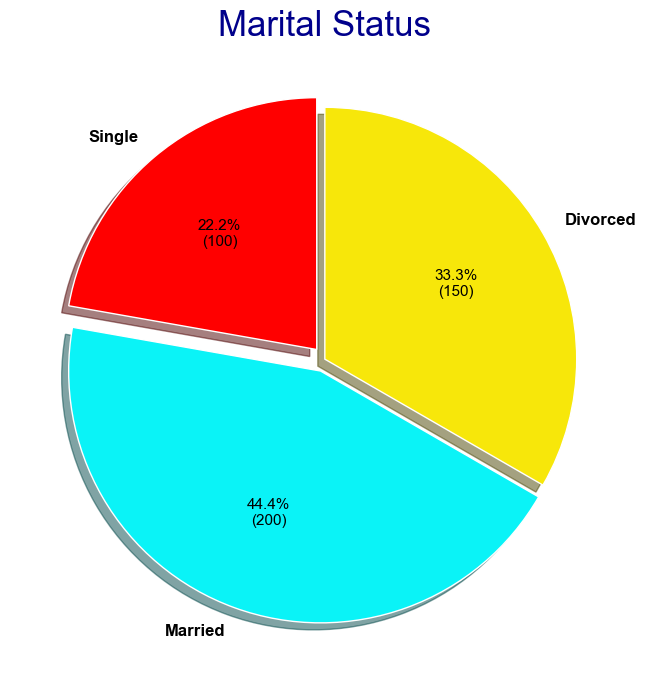

In [210]:
import matplotlib.pyplot as plt

# Sample data – replace with your actual data
label_counts = [100, 200, 150]
label = ['Single', 'Married', 'Divorced']

# Function to format percentage + absolute count
def funtion_for_value(pct, all_value):
    absolute = pct / 100 * sum(all_value)
    return "{:.1f}%\n({:d})".format(pct, round(absolute))

# Define slice colors
colors = ['#ff0000', '#0af3f7', '#f7e70a']  # Customize as needed

# Define text color
text_color = 'black'  # Can be any color like '#333333', 'white', etc.

# Plot pie chart and capture text handles
plt.figure(figsize=(7, 7))
explode = (0.05, 0.05, 0)

wedges, texts, autotexts = plt.pie(
    label_counts,
    labels=label,
    explode=explode,
    autopct=lambda pct: funtion_for_value(pct, label_counts),
    colors=colors,
    shadow=True,
    startangle=90
)

# Customize label text and percentage text
for text in texts:
    text.set_color(text_color)
    text.set_fontsize(12)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color(text_color)
    autotext.set_fontsize(11)

# Title and layout
plt.title('Marital Status', size=25, color='darkblue')
plt.tight_layout()
plt.show()

# Conclusion drawn from the plot

- Number of Married Employee : 673
- Number of Single Employee : 470
- Number of Divorced Employee : 327
- Clearly majority of the employees are married followed by singles and then divorced.

# Scatter Plots :

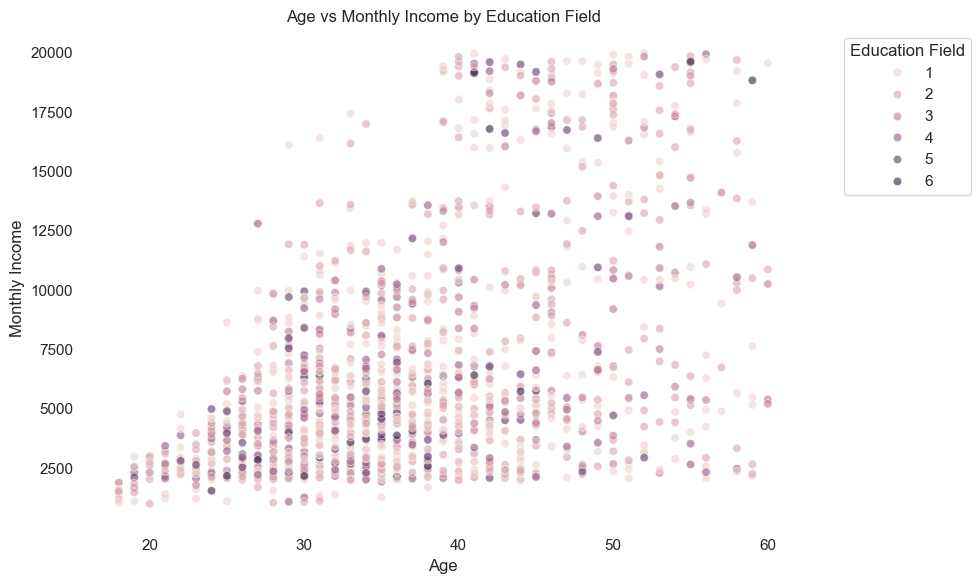

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: dataset with EducationField and Age
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dataset, x='Age', y='MonthlyIncome', hue='EducationField', alpha=0.6)

plt.title("Age vs Monthly Income by Education Field")
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.grid(True)
plt.legend(title='Education Field', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Heat Maps :

<b>1. Correlation Heatmap (most common) :</b>

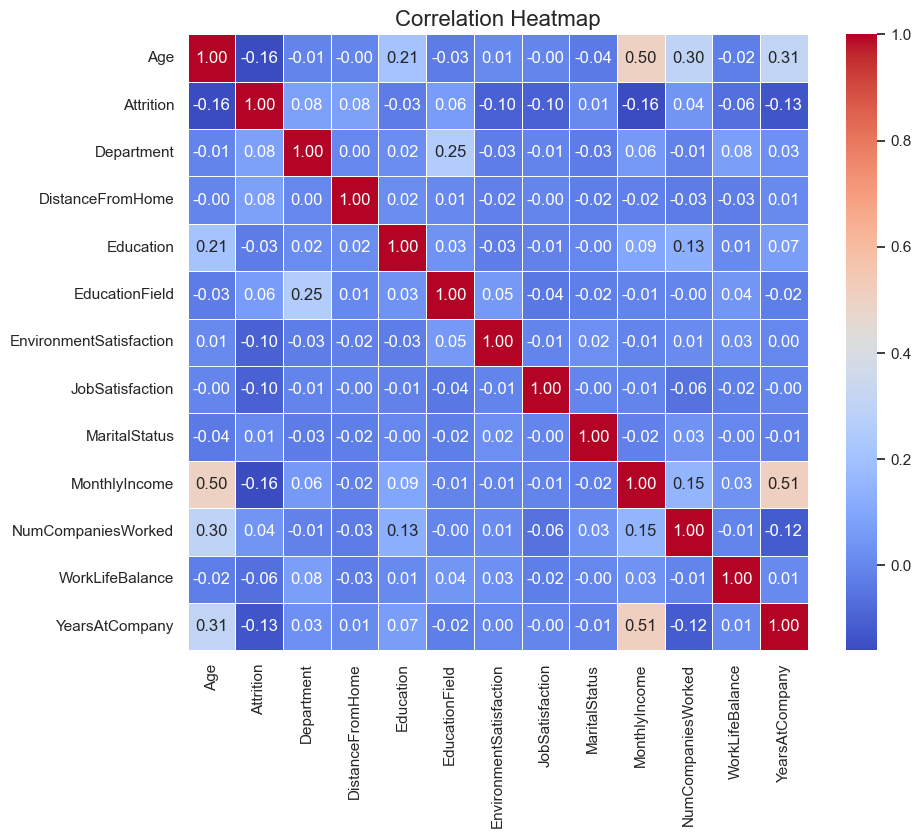

In [259]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = dataset.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

<b>2. Pivot-based Heatmap : (e.g., average age by department and gender)</b>

In [266]:
pivot_table = dataset.pivot_table(values='Age', index='Department', columns='Gender', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', linewidths=0.3)
plt.title("Average Age by Department and Gender", fontsize=14)
plt.show()

KeyError: 'Gender'

In [268]:
heat_data = dataset.groupby(['MaritalStatus', 'Gender']).size().unstack()

plt.figure(figsize=(7, 5))
sns.heatmap(heat_data, annot=True, cmap='Blues', fmt='d')
plt.title("Count of Employees by Marital Status and Gender")
plt.show()

KeyError: 'Gender'

# Model Building :

<b>We will use Logistic regression model for prediction</b>

In [216]:
dataset

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Research & Development,23,2,Medical,3,4,Married,2571,4,3,5
1466,39,No,Research & Development,6,1,Medical,4,1,Married,9991,4,3,7
1467,27,No,Research & Development,4,3,Life Sciences,2,2,Married,6142,1,3,6
1468,49,No,Sales,2,3,Medical,4,2,Married,5390,2,2,9


# we have a few categorical columns in the dataset

# we need to change the values into integer type

In [220]:
# Changing the Attrition column values
dataset['Attrition'].replace('Yes', 1, inplace=True)
dataset['Attrition'].replace('No', 0, inplace=True)

# Changing the Department Column Values
dataset['Department'].replace('Research & Development', 1, inplace=True)
dataset['Department'].replace('Sales', 2, inplace=True)
dataset['Department'].replace('Human Resources', 3, inplace=True)

# Changing the Educational Field values
dataset['EducationField'].replace('Life Sciences', 1, inplace=True)
dataset['EducationField'].replace('Medical', 2, inplace=True)
dataset['EducationField'].replace('Marketing', 3, inplace=True)
dataset['EducationField'].replace('Technical Degree', 4, inplace=True)
dataset['EducationField'].replace('Other', 5, inplace=True)
dataset['EducationField'].replace('Human Resources', 6, inplace=True)

# Changing the Maritial Status column values
dataset['MaritalStatus'].replace('Married', 1, inplace=True)
dataset['MaritalStatus'].replace('Single', 2, inplace=True)
dataset['MaritalStatus'].replace('Divorced', 3, inplace=True)

C:\Users\TSTRANSCO\AppData\Local\Temp\ipykernel_10644\2104454899.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Attrition'].replace('Yes', 1, inplace=True)
C:\Users\TSTRANSCO\AppData\Local\Temp\ipykernel_10644\2104454899.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [222]:
# view the dataset
dataset

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,1,2,1,2,1,2,4,2,5993,8,1,6
1,49,0,1,8,1,1,3,2,1,5130,1,3,10
2,37,1,1,2,2,5,4,3,2,2090,6,3,0
3,33,0,1,3,4,1,4,3,1,2909,1,3,8
4,27,0,1,2,1,2,1,2,1,3468,9,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,1,23,2,2,3,4,1,2571,4,3,5
1466,39,0,1,6,1,2,4,1,1,9991,4,3,7
1467,27,0,1,4,3,1,2,2,1,6142,1,3,6
1468,49,0,2,2,3,2,4,2,1,5390,2,2,9


In [224]:
# getting the features from the dataset
x_features = dataset.drop(['Attrition'], axis=1).copy()
x_features

,Age,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,2,1,2,1,2,4,2,5993,8,1,6
1,49,1,8,1,1,3,2,1,5130,1,3,10
2,37,1,2,2,5,4,3,2,2090,6,3,0
3,33,1,3,4,1,4,3,1,2909,1,3,8
4,27,1,2,1,2,1,2,1,3468,9,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,1,23,2,2,3,4,1,2571,4,3,5
1466,39,1,6,1,2,4,1,1,9991,4,3,7
1467,27,1,4,3,1,2,2,1,6142,1,3,6
1468,49,2,2,3,2,4,2,1,5390,2,2,9


In [226]:
# getting the target column from the dataset
y_target = dataset['Attrition'].copy()
y_target

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [228]:
# checking the type of the feature and target set
type(x_features), type(y_target)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [230]:
# Checking the shape of the feature and target shape
x_features.shape, y_target.shape

((1470, 12), (1470,))

In [232]:
# creating a model
model_1 = LogisticRegression(max_iter = 200) # maximum iteration increased to 200

# fitting the dataset to the model
model_1.fit(x_features, y_target)

# checking the score
model_1.score(x_features, y_target)

E:\Python Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8421768707482993

In [234]:
# target mean value
y_target.mean()

0.16122448979591836

In [236]:
# Splitting the dataset for better results
X_train, X_test, Y_train, Y_test = train_test_split(x_features, y_target, test_size=0.3, random_state=42)

In [238]:
# checking the shape of the split datasets
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1029, 12), (441, 12), (1029,), (441,))

In [240]:
# creating the model
model = LogisticRegression(max_iter = 200)

# fitting the model with the train and test dataset
model.fit(X_train, Y_train)

E:\Python Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [242]:
# Predicting the testing dataset
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [244]:
Y_test

1041    0
184     0
1222    1
67      0
220     0
       ..
1047    0
331     0
323     1
654     0
1110    1
Name: Attrition, Length: 441, dtype: int64

In [246]:
# Accuracy Score for our model
accuracy_score(Y_test, y_pred)

0.8639455782312925

In [248]:
# Root Mean Square
np.sqrt(mean_squared_error(Y_test, y_pred))

0.36885555678165877

In [250]:
# R_2 score for our model
from sklearn.metrics import r2_score
r2_score(Y_test, y_pred)

-0.14150129421915447

In [252]:
from sklearn import metrics
print(metrics.confusion_matrix(Y_test,y_pred))
print(metrics.classification_report(Y_test,y_pred))

[[377   3]
 [ 57   4]]
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       380
           1       0.57      0.07      0.12        61

    accuracy                           0.86       441
   macro avg       0.72      0.53      0.52       441
weighted avg       0.83      0.86      0.81       441



<h1><center><b>THE END</b></center></h1>